In [2]:
%pip install scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [234]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

## EDA

In [174]:
file_features_path = f'../data/feet_dataset_clean.csv'
file_labels_path = f'../data/feet_labels.csv'

feet_features_df = pd.read_csv(file_features_path)
feet_features_df.shape

(631, 6)

In [175]:
feet_features_df = feet_features_df[ feet_features_df['bad_photo'] != 1 ]
feet_features_df

,name,width,height,coin_width,foot_width,bad_photo
0,43_paulo_left_2.jpeg,1280,960,123,1061,0
1,43_paulo_left_3.jpeg,1280,960,118,1032,0
2,43_paulo_left_4.jpeg,1280,960,113,988,0
3,43_paulo_left_8.jpeg,1280,960,110,1025,0
4,43_paulo_left_9.jpeg,1280,960,109,1022,0
...,...,...,...,...,...,...
626,35_fiorella_left_10.png,1400,780,181,1265,0
627,35_fiorella_left_11.png,1398,756,148,1069,0
628,35_fiorella_left_15.png,1384,732,134,1013,0
629,35_fiorella_left_14.png,1398,802,159,1183,0


#### Merge features and labels dataframes

In [176]:
feet_labels_df = pd.read_csv(file_labels_path)
feet_labels_df.head(5)

,name,sex,foot_side,size_cm,size_eu
0,35_sandra_right,F,right,22.4,35
1,35_fiorella_left,M,left,21.8,35
2,35_mariluz_left,F,left,22.5,35
3,35_evelyn_left,F,left,23.5,36
4,doroti,F,left,23.1,36


In [177]:
# clean the extension in the names
feet_features_df['name_clean'] = feet_features_df['name'].str.rsplit('.', n=1).str[0]
feet_features_df['name_clean'] = feet_features_df['name_clean'].apply(lambda x: '_'.join(x.split('_')[:-1]) if x.split('_')[-1].isdigit() else x)
feet_features_df

,name,width,height,coin_width,foot_width,bad_photo,name_clean
0,43_paulo_left_2.jpeg,1280,960,123,1061,0,43_paulo_left
1,43_paulo_left_3.jpeg,1280,960,118,1032,0,43_paulo_left
2,43_paulo_left_4.jpeg,1280,960,113,988,0,43_paulo_left
3,43_paulo_left_8.jpeg,1280,960,110,1025,0,43_paulo_left
4,43_paulo_left_9.jpeg,1280,960,109,1022,0,43_paulo_left
...,...,...,...,...,...,...,...
626,35_fiorella_left_10.png,1400,780,181,1265,0,35_fiorella_left
627,35_fiorella_left_11.png,1398,756,148,1069,0,35_fiorella_left
628,35_fiorella_left_15.png,1384,732,134,1013,0,35_fiorella_left
629,35_fiorella_left_14.png,1398,802,159,1183,0,35_fiorella_left


In [271]:
full_feet_df = pd.merge(feet_features_df, feet_labels_df, how='left', left_on='name_clean', right_on='name')
full_feet_df

,name_x,width,height,coin_width,foot_width,bad_photo,name_clean,name_y,sex,foot_side,size_cm,size_eu
0,43_paulo_left_2.jpeg,1280,960,123,1061,0,43_paulo_left,43_paulo_left,M,left,27.2,43
1,43_paulo_left_3.jpeg,1280,960,118,1032,0,43_paulo_left,43_paulo_left,M,left,27.2,43
2,43_paulo_left_4.jpeg,1280,960,113,988,0,43_paulo_left,43_paulo_left,M,left,27.2,43
3,43_paulo_left_8.jpeg,1280,960,110,1025,0,43_paulo_left,43_paulo_left,M,left,27.2,43
4,43_paulo_left_9.jpeg,1280,960,109,1022,0,43_paulo_left,43_paulo_left,M,left,27.2,43
...,...,...,...,...,...,...,...,...,...,...,...,...
524,35_fiorella_left_10.png,1400,780,181,1265,0,35_fiorella_left,35_fiorella_left,M,left,21.8,35
525,35_fiorella_left_11.png,1398,756,148,1069,0,35_fiorella_left,35_fiorella_left,M,left,21.8,35
526,35_fiorella_left_15.png,1384,732,134,1013,0,35_fiorella_left,35_fiorella_left,M,left,21.8,35
527,35_fiorella_left_14.png,1398,802,159,1183,0,35_fiorella_left,35_fiorella_left,M,left,21.8,35


In [272]:
full_feet_df.isnull().sum()

name_x        0
width         0
height        0
coin_width    0
foot_width    0
bad_photo     0
name_clean    0
name_y        0
sex           0
foot_side     0
size_cm       0
size_eu       0
dtype: int64

In [273]:
full_feet_df[full_feet_df['name_y'].isnull()]

,name_x,width,height,coin_width,foot_width,bad_photo,name_clean,name_y,sex,foot_side,size_cm,size_eu


In [274]:
sel_columns = ["width", "height", "coin_width", "sex", "foot_side", "size_cm"]
feet_df = full_feet_df[sel_columns]

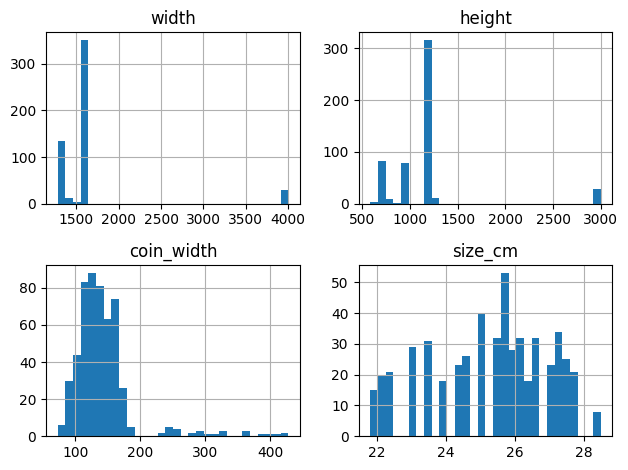

In [275]:
feet_df.hist(bins=30) 
plt.tight_layout()
plt.show()

In [276]:
full_feet_df[full_feet_df['width'] >= 4000]

,name_x,width,height,coin_width,foot_width,bad_photo,name_clean,name_y,sex,foot_side,size_cm,size_eu
107,36_magalyg_right_23.jpg,4000,3000,425,3336,0,36_magalyg_right,36_magalyg_right,F,right,23.0,36
108,36_magalyg_right_22.jpg,4000,3000,428,3371,0,36_magalyg_right,36_magalyg_right,F,right,23.0,36
109,36_magalyg_right_20.jpg,4000,3000,391,3089,0,36_magalyg_right,36_magalyg_right,F,right,23.0,36
110,36_magalyg_right_21.jpg,4000,3000,414,3274,0,36_magalyg_right,36_magalyg_right,F,right,23.0,36
111,36_magalyg_right_19.jpg,4000,3000,399,3148,0,36_magalyg_right,36_magalyg_right,F,right,23.0,36
112,36_magalyg_right_25.jpg,4000,3000,283,2361,0,36_magalyg_right,36_magalyg_right,F,right,23.0,36
113,36_magalyg_right_30.jpg,4000,3000,253,2070,0,36_magalyg_right,36_magalyg_right,F,right,23.0,36
114,36_magalyg_right_24.jpg,4000,3000,326,2696,0,36_magalyg_right,36_magalyg_right,F,right,23.0,36
115,36_magalyg_right_18.jpg,4000,3000,358,2797,0,36_magalyg_right,36_magalyg_right,F,right,23.0,36
116,36_magalyg_right_26.jpg,4000,3000,258,2196,-1,36_magalyg_right,36_magalyg_right,F,right,23.0,36


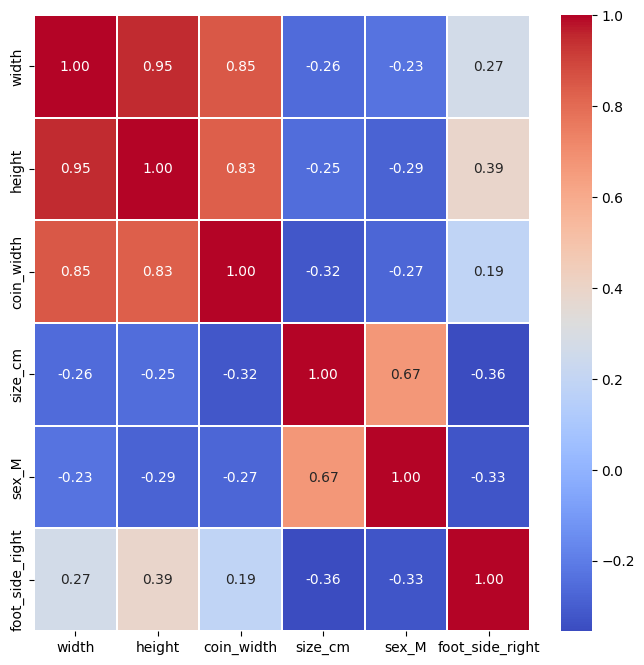

In [277]:
import seaborn as sns 

feet_encoded = pd.get_dummies(feet_df, columns=['sex', 'foot_side'],  drop_first=True)

corr_matrix = feet_encoded.corr()

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(8, 8))
ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=.3, cmap='coolwarm')

## Training a linear model

In [242]:

X = feet_encoded.drop(columns=['size_cm'])
y = feet_encoded["size_cm"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=32, shuffle=True)

# Escalar características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r_squared = model.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
coef = model.coef_
intercept = model.intercept_

print(f"R²: {r_squared}") # same r2_score(y_test, y_pred) = model.score(X_test, y_test)
# print(f"r2:", r2)
print(f"MSE: {mse}")
print(f"Coeficientes: {coef}")
print(f"Intercepto: {intercept}")

R²: 0.4588141510610536
MSE: 1.5324263656015378
Coeficientes: [-0.9043388   1.38070955 -0.56518526  1.06250436 -0.44172398]
Intercepto: 25.31843434343434


#### Inference

In [213]:
print("predictions:", list(y_pred[:5]))
print("ground-truth values:", list(y_test[:5].values))

predictions: [26.666532528181197, 26.520018690611906, 24.182968105723788, 26.643991937785923, 24.051502482549925]
ground-truth values: [26.0, 26.2, 23.0, 27.5, 25.0]


#### Plotting

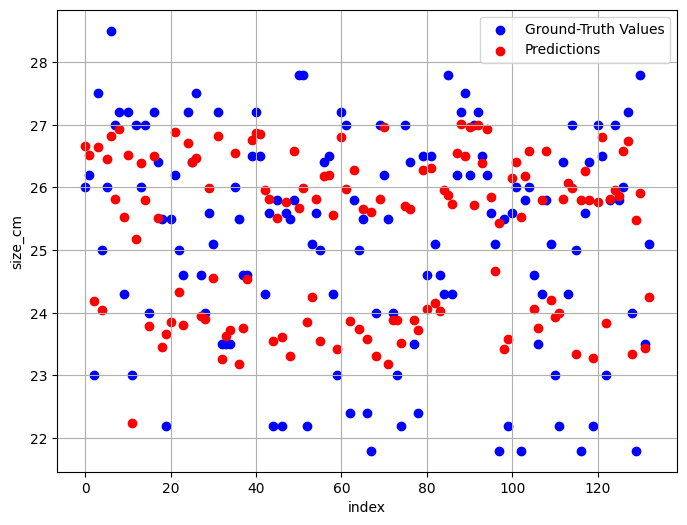

In [235]:
plt.figure(figsize=(8,6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Ground-Truth Values')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predictions')
plt.xlabel("index")
plt.ylabel("size_cm")
plt.legend()
plt.grid(True)
plt.show()

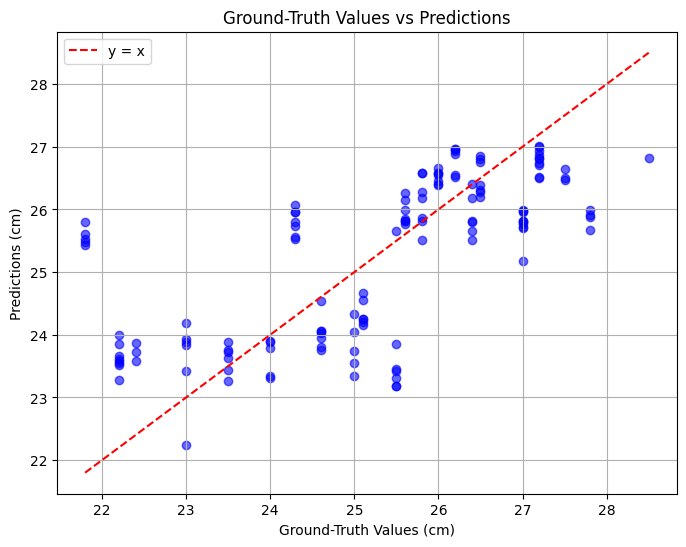

In [231]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='y = x')
plt.title("Ground-Truth Values vs Predictions")
plt.xlabel("Ground-Truth Values (cm)")
plt.ylabel("Predictions (cm)")
plt.legend()
plt.grid(True)

### Aplying Cross-Validation

In [239]:
from sklearn.model_selection import cross_val_score, KFold

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='r2')

print("R² per fold:", cv_scores)
print("R² average:", cv_scores.mean())

R² per fold: [0.48436689 0.60981177 0.53366994 0.58570288 0.40328592]
R² average: 0.5233674790195576


Small improvement. Let's try with another approach

### Aplying Polynomial Regression

In [259]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

max_degree = 5
results = []
for degree in range(1, max_degree):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=degree)),
        ('linear_model', LinearRegression())
    ])
    
    # Validación cruzada
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='r2')
    results.append({'degree': degree, 'mean_r2': scores.mean(), 'std_r2': scores.std()})
    print(f"Degree {degree}: R² average = {scores.mean():.4f}, std = {scores.std():.4f}")

Degree 1: R² average = 0.5234, std = 0.0740
Degree 2: R² average = 0.6144, std = 0.0866
Degree 3: R² average = 0.5822, std = 0.2717
Degree 4: R² average = -11.0159, std = 10.6931


In [260]:
#results.sort(key=lambda x: x['mean_r2'], reverse=True)
results_df = pd.DataFrame(results)
results_df

,degree,mean_r2,std_r2
0,1,0.523367,0.074034
1,2,0.614432,0.086642
2,3,0.582248,0.271707
3,4,-11.015894,10.693052


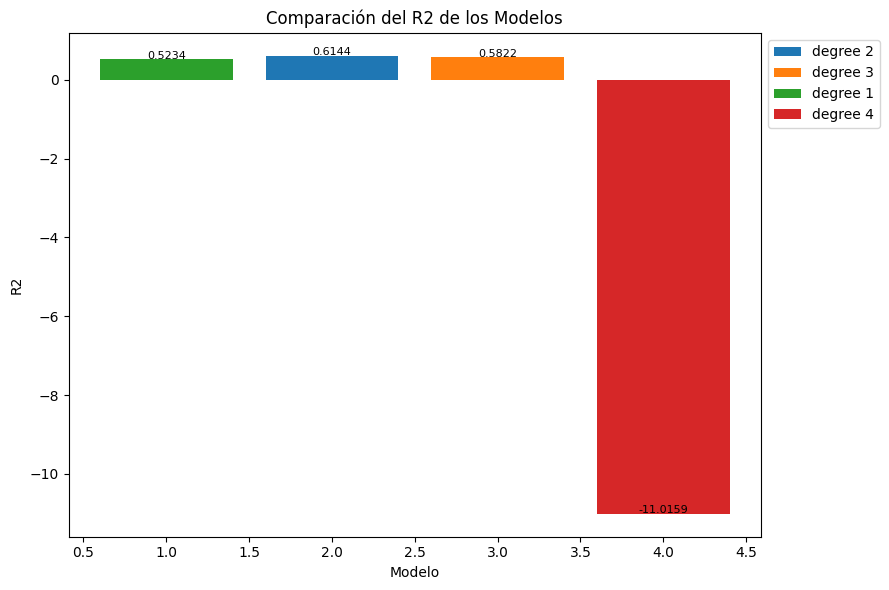

In [263]:
results_df_sorted = results_df.sort_values(by='mean_r2', ascending=False)

r2_values = results_df['mean_r2']
poly_degrees = results_df['degree']

plt.figure(figsize=(9, 6))
for degree, r2 in zip(poly_degrees, r2_values):
    plt.bar(degree, r2, label=f"degree {degree}")
    plt.text(degree, r2 + 0.01, f"{round(r2, 4)}", ha='center', fontsize=8)
plt.xlabel('Modelo')
plt.ylabel('R2')
plt.title('Comparación del R2 de los Modelos')
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

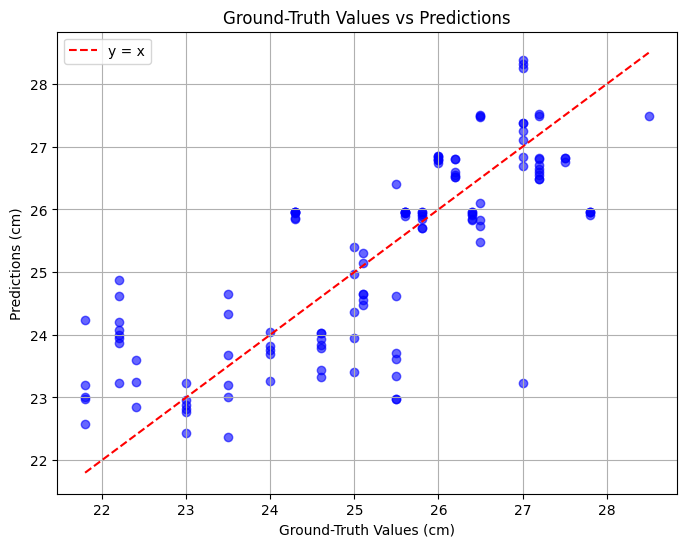

In [264]:
best_degree = 2
poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=best_degree)),
    ('linear_model', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred = poly_pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='y = x')
plt.title("Ground-Truth Values vs Predictions")
plt.xlabel("Ground-Truth Values (cm)")
plt.ylabel("Predictions (cm)")
plt.legend()
plt.grid(True)

In [266]:
print("predictions:", list(y_pred[:5]))
print("ground-truth values:", list(y_test[:5].values))

predictions: [26.743212086795396, 26.81137135993605, 22.425941982023495, 26.755525397918547, 24.969767208699544]
ground-truth values: [26.0, 26.2, 23.0, 27.5, 25.0]


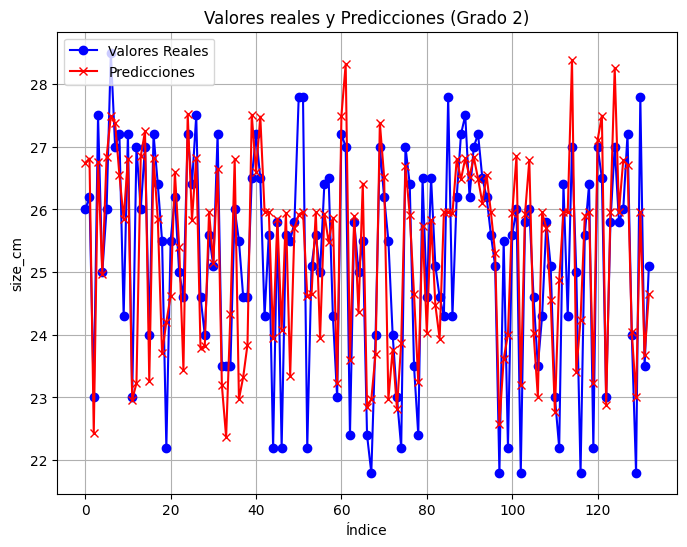

In [265]:
plt.figure(figsize=(8, 6))
plt.plot(range(len(y_test)), y_test, label='Valores Reales', color='blue', marker='o')
plt.plot(range(len(y_pred)), y_pred, label='Predicciones', color='red', marker='x')
plt.title(f"Valores reales y Predicciones (Grado {best_degree})")
plt.xlabel("Índice")
plt.ylabel("size_cm")
plt.legend()
plt.grid(True)
plt.show()